### Vectorized MicroGrad demo

This notebook mirrors `demo.ipynb`, but uses the NumPy-backed vectorized engine. The key idea is that one `Value` can hold an entire array, so a dense layer is built from a small number of array operations like `X @ W + b` instead of thousands of scalar `Value` operations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from vect_micrograd.vect_engine import Value
from vect_micrograd.vect_nn import MLP

np.random.seed(1337)

x = Value(np.random.randn(5, 3))
b = Value(np.random.randn(3))

y = x + b
loss = y.sum()
loss.backward()

assert b.grad.shape == b.data.shape
assert np.allclose(b.grad, np.ones(3) * 5)

#### Make a checkerboard dataset

A checkerboard requires a more expressive network than the moon demo. This is exactly where scalar micrograd becomes slow, because every neuron decomposes into many tiny Python objects. The vectorized version keeps the same dynamic-autograd idea while letting NumPy do the dense array work.

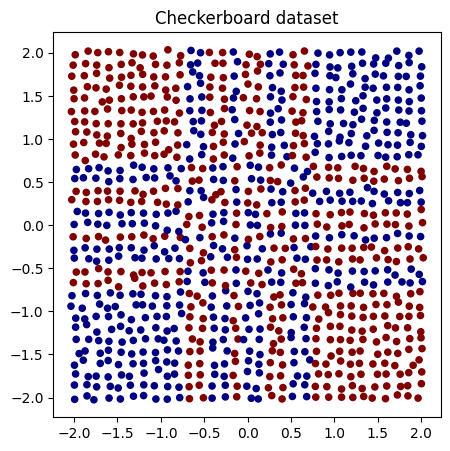

In [29]:
def make_checkerboard(n=400, grid=4, noise=0.02, seed=42):
    rng = np.random.default_rng(seed)
    side = int(np.sqrt(n))
    xs = np.linspace(-2, 2, side)
    ys = np.linspace(-2, 2, side)
    xx, yy = np.meshgrid(xs, ys)
    X = np.c_[xx.ravel(), yy.ravel()]

    ix = ((X[:, 0] + 1) / (2 / grid)).astype(int).clip(0, grid - 1)
    iy = ((X[:, 1] + 1) / (2 / grid)).astype(int).clip(0, grid - 1)
    y = ((ix + iy) % 2) * 2 - 1

    X += rng.normal(size=X.shape) * noise
    return X.astype(float), y.astype(float).reshape(-1, 1)

X, y = make_checkerboard(n=1000, grid=8, noise=0.02)

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), s=20, cmap='jet')
plt.title('Checkerboard dataset')
plt.show()

#### Initialize the vectorized model

`model.parameters()` now returns a small list of array-valued `Value` objects: one weight matrix and one bias vector per layer. The number of scalar trainable parameters is still large enough for the checkerboard, but the number of Python autograd nodes is much smaller.

In [30]:
# Create a 4-layer network: 2 inputs → 32 hidden → ... → 32 hidden → 1 output
model = MLP(2, [32, 32, 32, 1])

print(model)
print(f"number of scalar parameters: {sum(p.data.size for p in model.parameters()):,}")
print('number of Value parameter objects:', len(model.parameters()))

MLP of [Layer(2, 32), Layer(32, 32), Layer(32, 32), Layer(32, 1)]
number of scalar parameters: 2,241
number of Value parameter objects: 8


#### Optimization loop

In [31]:
from vect_micrograd.optim import SGD, Adam
from vect_micrograd.utils import save_checkpoint, load_checkpoint, svm_loss

steps = 8000

# optimizer = SGD(model.parameters(), lr=1.0, total_steps=steps)
optimizer = Adam(model.parameters(), lr=1e-2, total_steps=steps)

best_checkpoint = None
best_loss = float('inf')
best_step = -1
history = []

for k in range(steps):
    total_loss, acc = svm_loss(model, X, y)
    loss_value = total_loss.item()
    history.append((k, loss_value, acc))

    if loss_value < best_loss:
        best_loss = loss_value
        best_step = k
        best_checkpoint = save_checkpoint(model)

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step(k)

    if k % 100 == 0:
        print(f'step {k:03d} loss {loss_value:.4f}, accuracy {acc*100:.1f}%')

step 000 loss 1.2097, accuracy 50.1%
step 100 loss 0.6090, accuracy 69.7%
step 200 loss 0.4754, accuracy 78.6%
step 300 loss 0.4034, accuracy 83.4%
step 400 loss 0.3059, accuracy 88.8%
step 500 loss 0.3072, accuracy 88.9%
step 600 loss 0.2390, accuracy 92.6%
step 700 loss 0.2258, accuracy 92.0%
step 800 loss 0.1829, accuracy 94.7%
step 900 loss 0.1714, accuracy 95.4%
step 1000 loss 0.1593, accuracy 95.9%
step 1100 loss 0.1505, accuracy 96.6%
step 1200 loss 0.1329, accuracy 97.6%
step 1300 loss 0.1269, accuracy 97.9%
step 1400 loss 0.1278, accuracy 97.5%
step 1500 loss 0.1059, accuracy 98.1%
step 1600 loss 0.1041, accuracy 98.3%
step 1700 loss 0.1133, accuracy 98.2%
step 1800 loss 0.1034, accuracy 98.3%
step 1900 loss 0.1043, accuracy 98.3%
step 2000 loss 0.1029, accuracy 98.5%
step 2100 loss 0.0923, accuracy 98.8%
step 2200 loss 0.1041, accuracy 98.8%
step 2300 loss 0.0937, accuracy 98.6%
step 2400 loss 0.0857, accuracy 98.6%
step 2500 loss 0.1011, accuracy 98.9%
step 2600 loss 0.1002,

#### Restore the best checkpoint and evaluate on the full dataset

In [32]:
load_checkpoint(model, best_checkpoint)
full_loss, full_acc = svm_loss(model, X, y)

print(f'Restored checkpoint from step {best_step}, loss {best_loss:.4f}')
print(f'Full dataset: loss {full_loss.item():.4f}, accuracy {full_acc*100:.1f}%')


Restored checkpoint from step 7924, loss 0.0506
Full dataset: loss 0.0506, accuracy 99.8%


#### Training curve

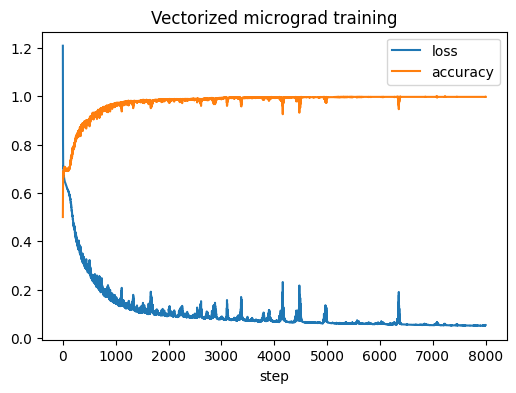

In [33]:
history = np.array(history)

plt.figure(figsize=(6, 4))
plt.plot(history[:, 0], history[:, 1], label='loss')
plt.plot(history[:, 0], history[:, 2], label='accuracy')
plt.xlabel('step')
plt.legend()
plt.title('Checkerboard test training')
plt.show()

#### Visualize the learned decision boundary

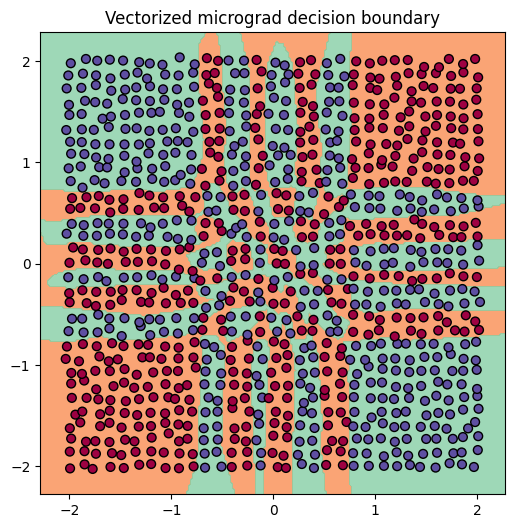

In [34]:
h = 0.02
x_min, x_max = X[:, 0].min() - 0.25, X[:, 0].max() + 0.25
y_min, y_max = X[:, 1].min() - 0.25, X[:, 1].max() + 0.25
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]

scores = model(Value(Xmesh))
Z = (scores.data > 0).reshape(xx.shape)

plt.figure(figsize=(6, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), s=40, cmap=plt.cm.Spectral, edgecolors='k')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title('Checkerboard test')
plt.show()

In [9]:
from tests.test_value import (
    test_softmax_ce_probabilities_sum_to_one,
    test_softmax_ce_numerical_gradient,
    test_softmax_ce_loss_is_mean,
    test_softmax_ce_respects_upstream_grad,
)

test_softmax_ce_probabilities_sum_to_one()
test_softmax_ce_numerical_gradient()
test_softmax_ce_loss_is_mean()
test_softmax_ce_respects_upstream_grad()

print("All softmax_ce tests passed.")

All softmax_ce tests passed.
